PREPROCESSING

In [14]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys

In [16]:
!git clone https://github.com/QIFEIDKN/STAGATE_pyG && cd STAGATE_pyG && python setup.py build && python setup.py install

running build
running build_py
creating build\lib\STAGATE_pyG
copying STAGATE_pyG\gat_conv.py -> build\lib\STAGATE_pyG
copying STAGATE_pyG\STAGATE.py -> build\lib\STAGATE_pyG
copying STAGATE_pyG\Train_STAGATE.py -> build\lib\STAGATE_pyG
copying STAGATE_pyG\utils.py -> build\lib\STAGATE_pyG
copying STAGATE_pyG\__init__.py -> build\lib\STAGATE_pyG
running egg_info
creating STAGATE_pyG.egg-info
writing STAGATE_pyG.egg-info\PKG-INFO
writing dependency_links to STAGATE_pyG.egg-info\dependency_links.txt
writing requirements to STAGATE_pyG.egg-info\requires.txt
writing top-level names to STAGATE_pyG.egg-info\top_level.txt
writing manifest file 'STAGATE_pyG.egg-info\SOURCES.txt'
reading manifest file 'STAGATE_pyG.egg-info\SOURCES.txt'
adding license file 'LICENSE'
writing manifest file 'STAGATE_pyG.egg-info\SOURCES.txt'
running install
running build
running build_py
copying STAGATE_pyG\gat_conv.py -> build\lib\STAGATE_pyG
copying STAGATE_pyG\STAGATE.py -> build\lib\STAGATE_pyG
copying STAGATE_

Cloning into 'STAGATE_pyG'...
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\setuptools\_distutils\cmd.py:90: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        This deprecation is overdue, please update your project and remove deprecated
        calls to avoid build errors in the future.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()


In [17]:
import torch
print(torch.__version__)

2.6.0+cu124


In [21]:
import torch
import STAGATE_pyG

In [22]:
import tqdm as notebook_tqdm

In [23]:
input_dir = 'data'
counts_file = os.path.join(input_dir, 'Puck_200127_15.digital_expression.txt')
coor_file = os.path.join(input_dir, 'Puck_200127_15_bead_locations.csv')

In [24]:
counts = pd.read_csv(counts_file, sep='\t', index_col=0)
coor_df = pd.read_csv(coor_file, index_col=0)
print(counts.shape, coor_df.shape)

(21220, 21724) (21724, 3)


In [25]:
print(coor_df.columns.tolist())
print(coor_df.head())

['xcoord', 'ycoord', 'barcode']
     xcoord  ycoord         barcode
0    10.298  3031.2  TTTTTTTTTTTTTT
1  3352.500  2498.0  GCTAGGATTGTAAA
2  3687.400  4701.0  CACAACAACGTTGG
3  2706.900  2504.5  AATGACGGCAATGC
4  2786.800  3984.3  TATTTTAGATCTCA


In [26]:
coor_df = pd.read_csv(coor_file, index_col=0)
coor_df.index = coor_df['barcode']

In [32]:
adata = sc.AnnData(counts.T)
adata.var_names_make_unique()
coor_df = coor_df.loc[adata.obs_names, ['xcoord', 'ycoord']]
adata.obsm["spatial"] = coor_df.to_numpy()

In [33]:
print(coor_df.index[:5])
print(adata.obs_names[:5])

Index(['TTTTTTTTTTTTTT', 'GCTAGGATTGTAAA', 'CACAACAACGTTGG', 'AATGACGGCAATGC',
       'TATTTTAGATCTCA'],
      dtype='object')
Index(['TTTTTTTTTTTTTT', 'GCTAGGATTGTAAA', 'CACAACAACGTTGG', 'AATGACGGCAATGC',
       'TATTTTAGATCTCA'],
      dtype='object')


In [34]:
sc.pp.calculate_qc_metrics(adata, inplace=True) #Compute quality control statistics (like total counts and number of genes per spot)
                                                #and store them inside the AnnData object for later filtering and analysis.

In [35]:
adata

AnnData object with n_obs × n_vars = 21724 × 21220
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

(np.float64(-289.81710000000004),
 np.float64(6312.7151),
 np.float64(173.30850000000004),
 np.float64(5709.8615))

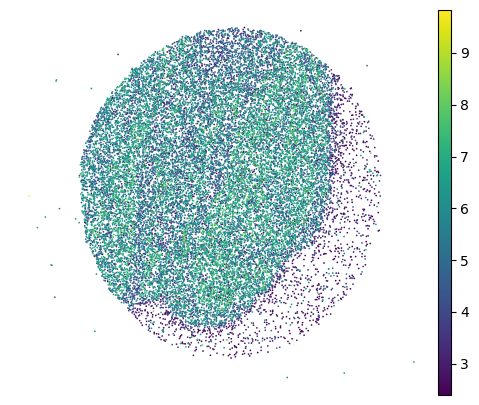

In [36]:
plt.rcParams["figure.figsize"] = (6,5)
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=6, show=False)
plt.title('')
plt.axis('off')

now we are removing the spots outside the main tissue area (filter the spots)

In [37]:
used_barcode = pd.read_csv('data/used_barcodes.txt', sep='\t', header=None)
used_barcode = used_barcode[0]

In [38]:
adata = adata[used_barcode,]

(np.float64(588.545),
 np.float64(5108.555),
 np.float64(847.6700000000001),
 np.float64(5670.73))

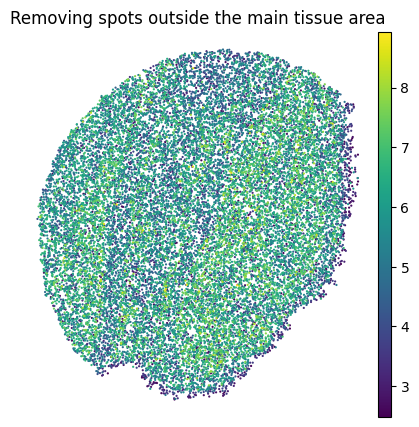

In [39]:
plt.rcParams["figure.figsize"] = (5,5)
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=10, show=False, title='Removing spots outside the main tissue area')

plt.axis('off')

filter the genes

In [40]:
sc.pp.filter_genes(adata, min_cells=50)
print('After flitering: ', adata.shape)

c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scanpy\preprocessing\_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


After flitering:  (20139, 11750)


now doing normalization

In [41]:
!{sys.executable} -m pip install scikit-misc


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

CONSTRUCTING THE SPATIAL NETWORK

------Calculating spatial graph...
The graph contains 228300 edges, 20139 cells.
11.3362 neighbors per cell on average.


c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\STAGATE_pyG\utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\STAGATE_pyG\utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))


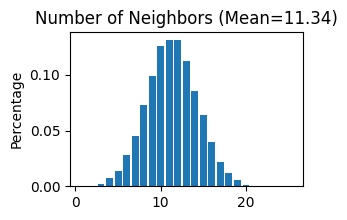

In [43]:
STAGATE_pyG.Cal_Spatial_Net(adata, rad_cutoff=50)
STAGATE_pyG.Stats_Spatial_Net(adata)

uninstalling current cpu version of torch and installing cuda version

In [44]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # Should print True

2.6.0+cu124
True


RUNNING STAGATE

In [45]:
adata = STAGATE_pyG.train_STAGATE(adata, device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:05<00:00,  7.97it/s]


now make neighbour graph and use umap to get 2d representation of the graph

In [46]:
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)

In [49]:
import sys
!{sys.executable} -m pip install igraph

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 1.2 MB/s eta 0:00:03
   --------- ------------------------------ 0.8/3.2 MB 1.3 MB/s eta 0:00:02
   ---------------- ----------------------- 1.3/3.2 MB 1.5 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.6 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.6 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.6 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.6 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.6 MB/s eta 0:00:02
   ---------------------- ----------------- 1.8/3.2 MB 832.2 kB/s eta 0:00:02
   ---------------------- ----------------- 1.8/3.2 MB 832.2 kB/s eta 0:00:02
   ---------------------- ---


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
!{sys.executable} -m pip install leidenalg

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   --------------------- ------------------ 1.0/2.0 MB 572.0 kB/s eta 0:00:02
   ------------------------------- -------- 1.6/2.0 MB 769.7 kB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 945.4 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
sc.tl.leiden(adata, resolution=0.5)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18364\2104492833.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [61]:
adata.obsm["spatial"] = adata.obsm["spatial"] * (-1)


(np.float64(-5108.555),
 np.float64(-588.545),
 np.float64(-5670.73),
 np.float64(-847.6700000000001))

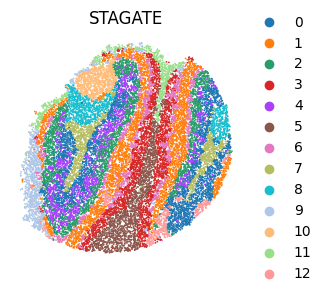

In [62]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.embedding(adata, basis="spatial", color="leiden",s=6, show=False, title='STAGATE')
plt.axis('off')

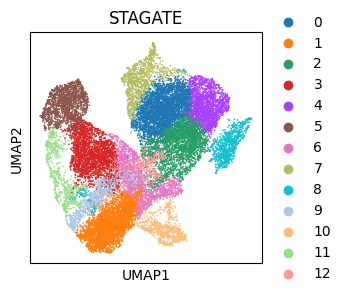

In [63]:
sc.pl.umap(adata, color='leiden', title='STAGATE')

NOW DO THE PERTURBATION ANALYSIS

In [64]:
import copy

adata_original = adata.copy()
adata_perturbed = adata.copy()

In [65]:
print(adata.var_names[adata.var['highly_variable']][:10].tolist())

['0610030E20Rik', '1110002L01Rik', '1110019D14Rik', '1190005I06Rik', '1200014J11Rik', '1500009C09Rik', '1500015O10Rik', '1500017E21Rik', '1600012H06Rik', '1700008J07Rik']


In [66]:
gene_that_is_perturbed = '1110002L01Rik'
adata_perturbed[:,gene_that_is_perturbed].X = 0

c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\anndata\_core\anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18364\1490439163.py:2: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:,gene_that_is_perturbed].X = 0
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


no need to reconstruct spatial network as it is based on physical coordinates of cells and not based on gene expressions.

In [68]:
adata_perturbed = STAGATE_pyG.train_STAGATE(adata_perturbed, device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:06<00:00,  7.91it/s]


In [69]:
sc.pp.neighbors(adata_perturbed, use_rep='STAGATE')
sc.tl.umap(adata_perturbed)

In [70]:
sc.tl.leiden(adata_perturbed, resolution=0.5)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18364\3608109182.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_perturbed, resolution=0.5)


In [71]:
adata_perturbed.obsm["spatial"] = adata_perturbed.obsm["spatial"] * (-1)

(np.float64(588.545),
 np.float64(5108.555),
 np.float64(847.6700000000001),
 np.float64(5670.73))

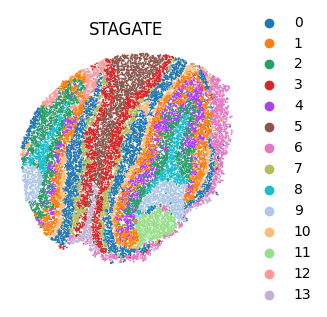

In [72]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.embedding(adata_perturbed, basis="spatial", color="leiden",s=6, show=False, title='STAGATE')
plt.axis('off')

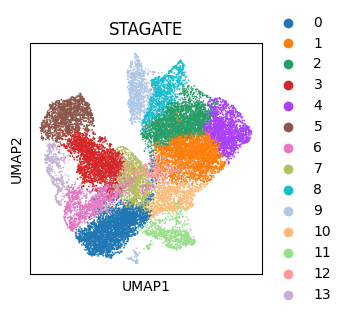

In [73]:
sc.pl.umap(adata_perturbed, color='leiden', title='STAGATE')

NOW FINDING THE ARI

In [77]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(adata.obs['leiden'], adata_perturbed.obs['leiden'])
print(ari)

0.7806400544082515
